# Iris Recognition System (Daugman's IrisCode)

A complete pipeline that:

1. **Segments** the iris using the Hough Transform.
2. **Normalizes** the circular iris into a 64 × 512 rectangle (rubber sheet model).
3. **Encodes** the texture using a bank of 2-D Gabor filters into a 2048-bit *IrisCode*.
4. **Matches** two IrisCodes using the Hamming Distance.
5. **Evaluates** the system with FAR / FRR / EER / ROC / AUC.

## Section 1 — Imports & Setup

We load all required libraries and verify that the dataset is in place.
If the `data/CASIA-IrisV1/` folder is missing, the next cell prints clear
instructions on how to obtain and place the dataset.

In [11]:
import os
import random
from itertools import combinations

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gabor_kernel
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

# Reproducibility
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

print('OpenCV version :', cv2.__version__)
print('NumPy  version :', np.__version__)

OpenCV version : 4.13.0
NumPy  version : 2.4.4


In [22]:
# ---- Dataset location check ----------------------------------------------
DATA_DIR = '/Users/aboubacarelhacen/nok/iris_recognition_project/data/CASIA-IrisV1'

def check_dataset(data_dir: str) -> bool:
    """Verify that the dataset directory exists and contains subject folders.

    Returns True if at least one subject folder with images is found,
    otherwise prints clear instructions and returns False.
    """
    if not os.path.isdir(data_dir):
        print(f'[ERROR] Dataset folder not found: {data_dir!r}')
        print('\nPlease download CASIA-IrisV1 (e.g. from Kaggle) and arrange it as:')
        print('  data/CASIA-IrisV1/001/001_1_1.jpg')
        print('  data/CASIA-IrisV1/001/001_1_2.jpg')
        print('  data/CASIA-IrisV1/002/...')
        return False
    subjects = [d for d in os.listdir(data_dir)
                if os.path.isdir(os.path.join(data_dir, d))]
    if not subjects:
        print(f'[ERROR] No subject sub-folders inside {data_dir!r}.')
        return False
    print(f'[OK] Found {len(subjects)} subject folders in {data_dir!r}.')
    return True

DATASET_OK = check_dataset(DATA_DIR)

[OK] Found 1000 subject folders in '/Users/aboubacarelhacen/nok/iris_recognition_project/data/CASIA-IrisV1'.


## Section 2 — Iris Segmentation

Each grayscale eye image is segmented with two calls to
`cv2.HoughCircles` — one tuned for the small dark **pupil** and one tuned
for the larger **limbus** (outer iris boundary).

If a circle cannot be detected, the function returns `None` and the image
is skipped further down the pipeline.

In [12]:
def load_gray_image(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'Could not read image: {path}')
    return img


def detect_pupil(gray: np.ndarray):
    """Detect the pupil (inner dark disc). Returns (cx, cy, r) or None."""
    blurred = cv2.medianBlur(gray, 5)
    h, w = gray.shape
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.0, minDist=h,
        param1=80, param2=25,
        minRadius=int(min(h, w) * 0.05),
        maxRadius=int(min(h, w) * 0.25),
    )
    if circles is None:
        return None
    cx, cy, r = np.round(circles[0, 0]).astype(int)
    return int(cx), int(cy), int(r)


def detect_iris(gray: np.ndarray, pupil):
    """Detect the outer iris boundary (limbus). Returns (cx, cy, r) or None."""
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    h, w = gray.shape
    pcx, pcy, pr = pupil
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.0, minDist=h,
        param1=80, param2=30,
        minRadius=max(int(pr * 2.0), 1),
        maxRadius=int(min(h, w) * 0.5),
    )
    if circles is None:
        return pcx, pcy, int(pr * 2.5)
    best = min(circles[0], key=lambda c: (c[0] - pcx) ** 2 + (c[1] - pcy) ** 2)
    cx, cy, r = np.round(best).astype(int)
    return int(cx), int(cy), int(r)


def segment_iris(gray: np.ndarray):
    """Run pupil + iris detection. Returns (pupil, iris) or None on failure."""
    pupil = detect_pupil(gray)
    if pupil is None:
        return None
    iris = detect_iris(gray, pupil)
    if iris is None or iris[2] <= pupil[2]:
        return None
    return pupil, iris


Sample image: /Users/aboubacarelhacen/nok/iris_recognition_project/data/CASIA-IrisV1/000/R/S5000R00.jpg


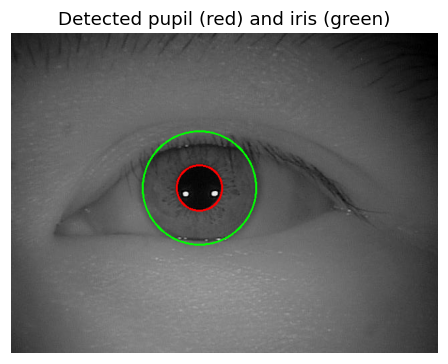

In [13]:
# ---- Sample segmentation visualization -----------------------------------
SAMPLE_IMAGE = None
if DATASET_OK:
    for subj in sorted(os.listdir(DATA_DIR)):
        subj_dir = os.path.join(DATA_DIR, subj)
        if not os.path.isdir(subj_dir):
            continue
        found = False
        for root, _dirs, files in os.walk(subj_dir):
            for f in sorted(files):
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    SAMPLE_IMAGE = os.path.join(root, f)
                    found = True
                    break
            if found:
                break
        if found:
            break

if SAMPLE_IMAGE:
    sample_gray = load_gray_image(SAMPLE_IMAGE)
    seg = segment_iris(sample_gray)
    print('Sample image:', SAMPLE_IMAGE)
    if seg:
        pupil, iris = seg
        vis = cv2.cvtColor(sample_gray, cv2.COLOR_GRAY2BGR)
        cv2.circle(vis, (pupil[0], pupil[1]), pupil[2], (0, 0, 255), 2)
        cv2.circle(vis, (iris[0], iris[1]), iris[2], (0, 255, 0), 2)
        plt.figure(figsize=(5, 5))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title('Detected pupil (red) and iris (green)')
        plt.axis('off')
        plt.show()
    else:
        print('Segmentation failed on the sample image.')
else:
    print('No sample image available — dataset is missing or empty.')

## Section 3 — Daugman Rubber Sheet Normalization

We unwrap the annular iris region into a rectangular block of
**64 rows × 512 columns** using the polar mapping introduced by
Daugman:

$$
x(r,\theta) = (1-r)\,x_p(\theta) + r\,x_i(\theta), \qquad
y(r,\theta) = (1-r)\,y_p(\theta) + r\,y_i(\theta)
$$

where $r \in [0,1]$ is the radial coordinate (rows) and
$\theta \in [0, 2\pi)$ is the angular coordinate (columns).

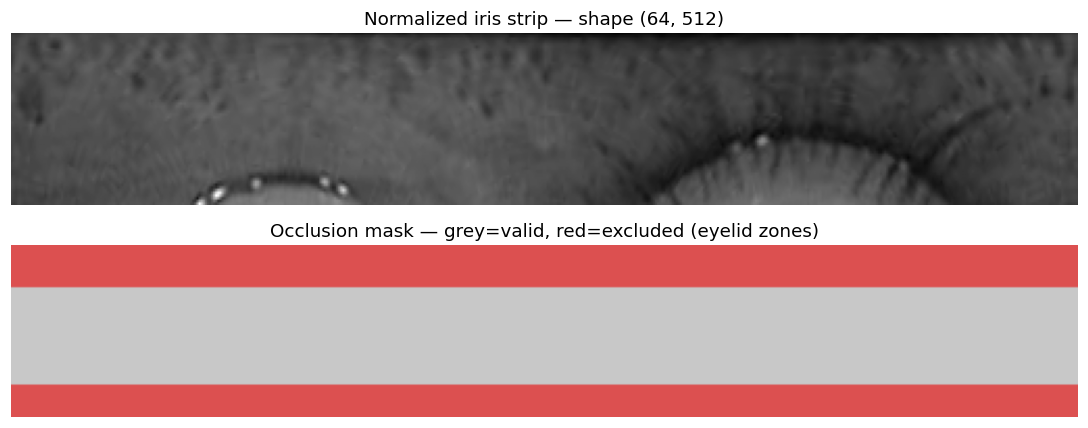

In [14]:
NORM_HEIGHT = 64
NORM_WIDTH  = 512

# Rows where eyelids typically appear — top ~25% and bottom ~20% of the strip.
# These fractions exclude the most occluded rows from matching.
EYELID_TOP_FRAC    = 0.25
EYELID_BOTTOM_FRAC = 0.20


def normalize_iris(gray: np.ndarray, pupil, iris,
                   height: int = NORM_HEIGHT,
                   width: int  = NORM_WIDTH):
    """Daugman rubber-sheet normalization.

    Returns
    -------
    normalized : height × width uint8 array (the unwrapped iris strip)
    mask       : height × width bool array  (True = valid pixel, False = occluded)
    """
    pcx, pcy, pr = pupil
    icx, icy, ir = iris

    theta = np.linspace(0.0, 2.0 * np.pi, width,  endpoint=False)
    r_lin = np.linspace(0.0, 1.0,          height)

    x_p = pcx + pr * np.cos(theta)
    y_p = pcy + pr * np.sin(theta)
    x_i = icx + ir * np.cos(theta)
    y_i = icy + ir * np.sin(theta)

    R     = r_lin[:, None]
    map_x = ((1.0 - R) * x_p[None, :] + R * x_i[None, :]).astype(np.float32)
    map_y = ((1.0 - R) * y_p[None, :] + R * y_i[None, :]).astype(np.float32)

    normalized = cv2.remap(gray, map_x, map_y,
                           interpolation=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_REPLICATE)

    # Build eyelid mask: exclude top and bottom rows where lids occlude the iris
    mask = np.ones((height, width), dtype=bool)
    top_rows    = int(height * EYELID_TOP_FRAC)
    bottom_rows = int(height * EYELID_BOTTOM_FRAC)
    mask[:top_rows,  :]  = False   # upper eyelid zone
    mask[-bottom_rows:, :] = False  # lower eyelid zone

    return normalized, mask


if SAMPLE_IMAGE and seg:
    norm, mask = normalize_iris(sample_gray, *seg)

    import matplotlib.patches as mpatches
    fig, axes = plt.subplots(2, 1, figsize=(10, 4))
    axes[0].imshow(norm, cmap='gray', aspect='auto')
    axes[0].set_title(f'Normalized iris strip — shape {norm.shape}')
    axes[0].axis('off')

    vis_mask = np.zeros((*norm.shape, 3), dtype=np.uint8)
    vis_mask[mask]  = [200, 200, 200]   # grey = valid
    vis_mask[~mask] = [220, 80,  80]    # red  = eyelid / excluded
    axes[1].imshow(vis_mask, aspect='auto')
    axes[1].set_title('Occlusion mask — grey=valid, red=excluded (eyelid zones)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


## Section 4 — IrisCode Extraction (Gabor Filtering)

We convolve the normalized strip with a small bank of 2-D Gabor filters
at four orientations (0°, 45°, 90°, 135°). Each response is binarised
(`>0 → 1`) and then **downsampled** so that the concatenation of all
four orientations yields exactly **2048 bits** per iris.

With a normalized strip of 64 × 512 we average the responses into
non-overlapping blocks of 8 × 8, giving 8 × 64 = 512 bits per orientation
→ 4 × 512 = 2048 bits total.

In [16]:
GABOR_ORIENTATIONS = [0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GABOR_FREQUENCY    = 0.25
BLOCK_H, BLOCK_W   = 8, 8
BITS_PER_ORI = (NORM_HEIGHT // BLOCK_H) * (NORM_WIDTH // BLOCK_W)
IRISCODE_BITS = BITS_PER_ORI * len(GABOR_ORIENTATIONS)
assert IRISCODE_BITS == 2048, f'Expected 2048 bits, got {IRISCODE_BITS}'

from skimage.filters import gabor_kernel
_GABOR_KERNELS = [
    np.imag(gabor_kernel(frequency=GABOR_FREQUENCY, theta=t)).astype(np.float32)
    for t in GABOR_ORIENTATIONS
]


def _block_mean(arr: np.ndarray, bh: int, bw: int) -> np.ndarray:
    h, w = arr.shape
    arr  = arr[: h // bh * bh, : w // bw * bw]
    return arr.reshape(h // bh, bh, w // bw, bw).mean(axis=(1, 3))


def extract_iriscode(normalized: np.ndarray, mask: np.ndarray):
    """Return (iriscode, noise_mask) both length-2048 uint8 arrays.

    noise_mask[i] = 1 means bit i is valid; 0 means it was in an occluded zone.
    """
    img   = normalized.astype(np.float32) / 255.0
    bits  = []
    nmask = []
    for kernel in _GABOR_KERNELS:
        response  = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=kernel)
        pooled    = _block_mean(response, BLOCK_H, BLOCK_W)
        mask_pool = _block_mean(mask.astype(np.float32), BLOCK_H, BLOCK_W)
        bits.append((pooled > 0).astype(np.uint8).ravel())
        nmask.append((mask_pool > 0.5).astype(np.uint8).ravel())
    return np.concatenate(bits), np.concatenate(nmask)


if SAMPLE_IMAGE and seg:
    code, noise_mask = extract_iriscode(norm, mask)
    valid_pct = noise_mask.mean() * 100
    print(f'IrisCode length : {code.size} bits')
    print(f'Valid bits      : {valid_pct:.1f}%  ({noise_mask.sum()} / {noise_mask.size})')
    print(f'First 64 bits   : {code[:64]}')


IrisCode length : 2048 bits
Valid bits      : 50.0%  (1024 / 2048)
First 64 bits   : [1 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 1
 1 0 1 1 0 1 0 0 1 0 1 0 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0]


## Section 5 — Hamming Distance Matching

The standard matching score for IrisCodes is the **normalized Hamming
distance**:

$$
\mathrm{HD}(a,b) = \frac{1}{N}\sum_{i=1}^{N} a_i \oplus b_i
$$

An HD below ~0.32 indicates the same person; above suggests different
people.

In [17]:
# Each column-block rotation = NORM_HEIGHT//BLOCK_H = 8 bits per orientation band.
# We try ±ROTATION_SHIFTS column shifts and keep the minimum HD.
ROTATION_SHIFTS = 8   # try ±8 column-block shifts (~±45° rotation tolerance)
BITS_PER_COL_BLOCK = NORM_HEIGHT // BLOCK_H   # 8 bits shift per column step


def hamming_distance(code1: np.ndarray, code2: np.ndarray,
                     mask1: np.ndarray = None,
                     mask2: np.ndarray = None) -> float:
    """Rotation-tolerant masked Hamming Distance.

    Tries circular shifts of ±ROTATION_SHIFTS column blocks across all
    orientation bands and returns the minimum HD over valid bits.
    """
    if code1.shape != code2.shape:
        raise ValueError('IrisCodes must have the same length.')

    n_ori   = len(GABOR_ORIENTATIONS)
    band    = len(code1) // n_ori   # bits per orientation (512)
    step    = BITS_PER_COL_BLOCK    # bits per column-block shift (8)

    best_hd = 1.0
    for shift in range(-ROTATION_SHIFTS, ROTATION_SHIFTS + 1):
        shift_bits = shift * step
        rolled1 = np.empty_like(code1)
        rolledm1 = np.empty_like(mask1) if mask1 is not None else None
        for o in range(n_ori):
            s, e = o * band, (o + 1) * band
            rolled1[s:e] = np.roll(code1[s:e], shift_bits)
            if rolledm1 is not None:
                rolledm1[s:e] = np.roll(mask1[s:e], shift_bits)

        if rolledm1 is not None and mask2 is not None:
            valid = (rolledm1 == 1) & (mask2 == 1)
            if valid.sum() < 100:
                continue
            hd = float(np.mean(rolled1[valid] != code2[valid]))
        else:
            hd = float(np.mean(rolled1 != code2))

        if hd < best_hd:
            best_hd = hd

    return best_hd


# Quick self-test
_a = np.array([0, 1, 0, 1, 1, 0, 0, 1] * 256, dtype=np.uint8)
_b = np.roll(_a, 8)   # one column-block shift — should match perfectly
_m = np.ones(2048, dtype=np.uint8)
assert hamming_distance(_a, _a, _m, _m) == 0.0
assert hamming_distance(_a, _b, _m, _m) == 0.0, "rotation shift not corrected"
print('hamming_distance(): rotation-tolerant masked checks passed.')


hamming_distance(): rotation-tolerant masked checks passed.


## Section 6 — Dataset Preparation

We walk through `data/CASIA-IrisV1/`, segment + normalize + encode every
image, and store a list of records. From those records we build:

* **Genuine pairs** – pairs of images from the *same* subject.
* **Impostor pairs** – pairs from *different* subjects, randomly
  sampled and capped at the same number as the genuine pairs.

Failures (segmentation errors, unreadable files) are caught and
reported, not raised.

In [18]:
# Cap the number of distinct subjects (eyes) processed.
# CASIA-Iris-Thousand has 1000 subjects × 2 eyes × ~10 images = ~20 000 images,
# which takes a long time. With MAX_SUBJECTS=50 the notebook runs in a few minutes
# and still produces meaningful FAR/FRR/EER curves. Set to None to use everything.
MAX_SUBJECTS = None


def collect_image_paths(data_dir: str, max_subjects=None):
    """Return list of ``(subject_id, image_path)`` for every iris image found.

    Handles two folder layouts transparently:
      * CASIA-IrisV1         : ``subject/*.jpg``
      * CASIA-Iris-Thousand  : ``subject/{L,R}/*.jpg`` — left and right eyes are
        biometrically distinct, so each is treated as its own "subject"
        (e.g. ``000_L``, ``000_R``).
    """
    items = []
    if not os.path.isdir(data_dir):
        return items
    top_dirs = sorted(d for d in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, d)))
    for subj in top_dirs:
        subj_dir = os.path.join(data_dir, subj)
        sub = sorted(d for d in os.listdir(subj_dir)
                     if os.path.isdir(os.path.join(subj_dir, d)))
        if sub and all(s.upper() in ('L', 'R') for s in sub):
            for eye in sub:
                eye_dir = os.path.join(subj_dir, eye)
                sid = f'{subj}_{eye.upper()}'
                for f in sorted(os.listdir(eye_dir)):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                        items.append((sid, os.path.join(eye_dir, f)))
        else:
            for root, _dirs, files in os.walk(subj_dir):
                for f in sorted(files):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                        items.append((subj, os.path.join(root, f)))

    if max_subjects is not None:
        kept_set = set()
        kept_items = []
        for sid, path in items:
            if sid not in kept_set:
                if len(kept_set) >= max_subjects:
                    continue
                kept_set.add(sid)
            if sid in kept_set:
                kept_items.append((sid, path))
        items = kept_items
    return items


def process_image(path: str):
    """Full pipeline for one image. Returns (iriscode, noise_mask) or None on failure."""
    try:
        gray = load_gray_image(path)
        seg_result = segment_iris(gray)
        if seg_result is None:
            return None
        pupil, iris = seg_result
        normalized, mask = normalize_iris(gray, pupil, iris)
        return extract_iriscode(normalized, mask)
    except Exception as exc:                       # noqa: BLE001
        print(f'[WARN] {path}: {exc}')
        return None


records = []
fail_count = 0

if DATASET_OK:
    all_items = collect_image_paths(DATA_DIR, max_subjects=MAX_SUBJECTS)
    n_subj_seen = len({s for s, _ in all_items})
    print(f'Found {len(all_items)} image files across {n_subj_seen} '
          f'subject(s)/eye(s). Processing...')
    for subj, path in tqdm(all_items, desc='Encoding irises'):
        result = process_image(path)
        if result is None:
            fail_count += 1
            continue
        code_bits, noise_mask = result
        records.append({
            'subject_id': subj,
            'image_path': path,
            'iriscode':   code_bits,
            'noise_mask': noise_mask,
        })
    print(f'\nSuccessfully encoded: {len(records)} / {len(all_items)} '
          f'(failures: {fail_count})')
else:
    print('Dataset missing — skipping encoding stage.')


Found 20000 image files across 2000 subject(s)/eye(s). Processing...


Encoding irises: 100%|██████████| 20000/20000 [02:18<00:00, 144.37it/s]


Successfully encoded: 19901 / 20000 (failures: 99)


In [19]:
# ---- Build genuine and impostor pairs ------------------------------------
genuine_hd = []
impostor_hd = []

if records:
    # Group records by subject
    by_subject = {}
    for rec in records:
        by_subject.setdefault(rec['subject_id'], []).append(rec)

    # Genuine pairs
    genuine_pairs = []
    for subj, recs in by_subject.items():
        if len(recs) >= 2:
            genuine_pairs.extend(combinations(recs, 2))
    print(f'Genuine pairs : {len(genuine_pairs)}')

    for a, b in tqdm(genuine_pairs, desc='HD (genuine)'):
        genuine_hd.append(hamming_distance(a['iriscode'], b['iriscode'], a['noise_mask'], b['noise_mask']))

    # Impostor pairs — random sample of distinct-subject pairs,
    # capped at len(genuine_pairs) for a balanced evaluation.
    target = max(len(genuine_pairs), 1)
    subjects = list(by_subject.keys())
    seen = set()
    impostor_pairs = []
    attempts = 0
    max_attempts = target * 50
    while len(impostor_pairs) < target and attempts < max_attempts and len(subjects) > 1:
        s1, s2 = random.sample(subjects, 2)
        a = random.choice(by_subject[s1])
        b = random.choice(by_subject[s2])
        key = (a['image_path'], b['image_path'])
        key_rev = (b['image_path'], a['image_path'])
        if key in seen or key_rev in seen:
            attempts += 1
            continue
        seen.add(key)
        impostor_pairs.append((a, b))
        attempts += 1
    print(f'Impostor pairs: {len(impostor_pairs)}')

    for a, b in tqdm(impostor_pairs, desc='HD (impostor)'):
        impostor_hd.append(hamming_distance(a['iriscode'], b['iriscode'], a['noise_mask'], b['noise_mask']))

genuine_hd = np.asarray(genuine_hd)
impostor_hd = np.asarray(impostor_hd)
print('\nGenuine  HD: mean={:.4f}  std={:.4f}'.format(
    genuine_hd.mean() if genuine_hd.size else float('nan'),
    genuine_hd.std()  if genuine_hd.size else float('nan')))
print('Impostor HD: mean={:.4f}  std={:.4f}'.format(
    impostor_hd.mean() if impostor_hd.size else float('nan'),
    impostor_hd.std()  if impostor_hd.size else float('nan')))

Genuine pairs : 89188


HD (genuine): 100%|██████████| 89188/89188 [01:05<00:00, 1356.10it/s]


Impostor pairs: 89188


HD (impostor): 100%|██████████| 89188/89188 [01:06<00:00, 1349.97it/s]


Genuine  HD: mean=0.4510  std=0.0281
Impostor HD: mean=0.4640  std=0.0116


## Section 7 — Evaluation: FAR, FRR, EER

We sweep the HD threshold from 0.0 to 1.0 in 0.01 increments. For each
threshold:

* **FAR** = fraction of impostor pairs with HD ≤ threshold (false accept).
* **FRR** = fraction of genuine pairs with HD > threshold (false reject).

The **EER** is the threshold where `|FAR − FRR|` is minimal.

In [20]:
thresholds = np.arange(0.0, 1.0001, 0.01)
far = np.zeros_like(thresholds)
frr = np.zeros_like(thresholds)

if genuine_hd.size and impostor_hd.size:
    for k, thr in enumerate(thresholds):
        far[k] = np.mean(impostor_hd <= thr)
        frr[k] = np.mean(genuine_hd  >  thr)

    diff = np.abs(far - frr)
    eer_idx = int(np.argmin(diff))
    eer_threshold = float(thresholds[eer_idx])
    eer = float((far[eer_idx] + frr[eer_idx]) / 2.0)
    far_at_eer = float(far[eer_idx])
    frr_at_eer = float(frr[eer_idx])

    # ROC / AUC — label genuine = 1, impostor = 0; lower HD = more genuine
    y_true = np.concatenate([np.ones_like(genuine_hd), np.zeros_like(impostor_hd)])
    y_score = np.concatenate([-genuine_hd, -impostor_hd])     # higher = more genuine
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_score = float(auc(fpr, tpr))

    print(f'EER          : {eer*100:.2f}%')
    print(f'FAR @ EER    : {far_at_eer*100:.2f}%')
    print(f'FRR @ EER    : {frr_at_eer*100:.2f}%')
    print(f'EER threshold: {eer_threshold:.2f}')
    print(f'AUC          : {auc_score:.4f}')
else:
    eer = far_at_eer = frr_at_eer = eer_threshold = auc_score = float('nan')
    fpr = tpr = np.array([])
    print('Not enough data for evaluation.')

EER          : 38.99%
FAR @ EER    : 34.10%
FRR @ EER    : 43.89%
EER threshold: 0.46
AUC          : 0.6572


## Section 8 — Visualizations

1. Sample original eye image with detected iris/pupil circles overlaid.
2. Normalized (unwrapped) iris strip.
3. IrisCode rendered as a binary heatmap.
4. Genuine vs impostor HD histograms.
5. FAR / FRR curves vs threshold (EER point marked).
6. ROC curve with AUC.

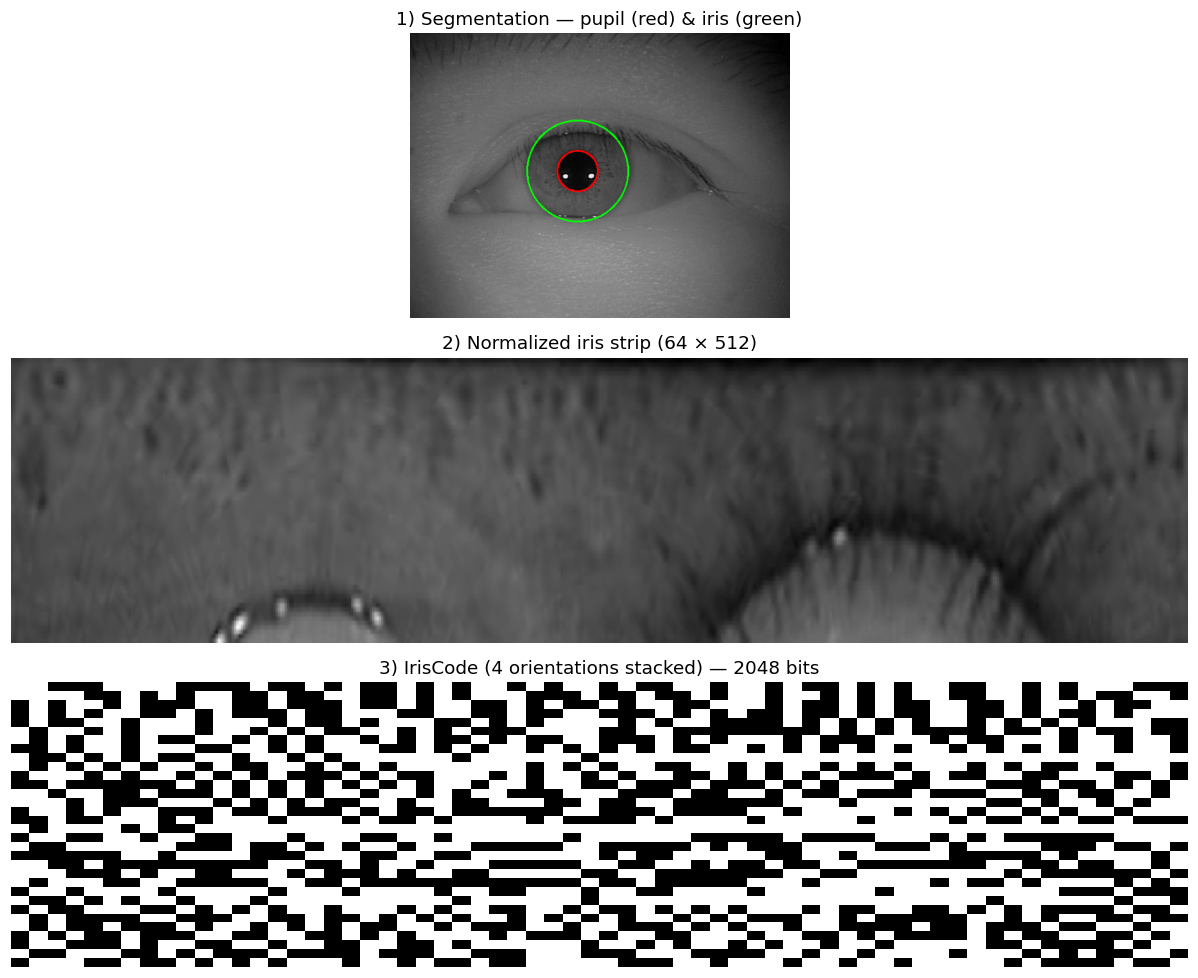

In [21]:
# (1) Segmentation overlay  /  (2) normalized strip  /  (3) IrisCode heatmap
if SAMPLE_IMAGE and seg:
    pupil, iris = seg
    overlay = cv2.cvtColor(sample_gray, cv2.COLOR_GRAY2BGR)
    cv2.circle(overlay, (pupil[0], pupil[1]), pupil[2], (0, 0, 255), 2)
    cv2.circle(overlay, (iris[0], iris[1]), iris[2], (0, 255, 0), 2)

    code_2d = code.reshape(len(GABOR_ORIENTATIONS),
                           NORM_HEIGHT // BLOCK_H,
                           NORM_WIDTH // BLOCK_W)
    code_img = np.vstack(list(code_2d))    # stack orientations vertically

    fig, axes = plt.subplots(3, 1, figsize=(11, 9))
    axes[0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[0].set_title('1) Segmentation — pupil (red) & iris (green)')
    axes[0].axis('off')

    axes[1].imshow(norm, cmap='gray', aspect='auto')
    axes[1].set_title('2) Normalized iris strip (64 × 512)')
    axes[1].axis('off')

    axes[2].imshow(code_img, cmap='gray', aspect='auto', interpolation='nearest')
    axes[2].set_title('3) IrisCode (4 orientations stacked) — 2048 bits')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

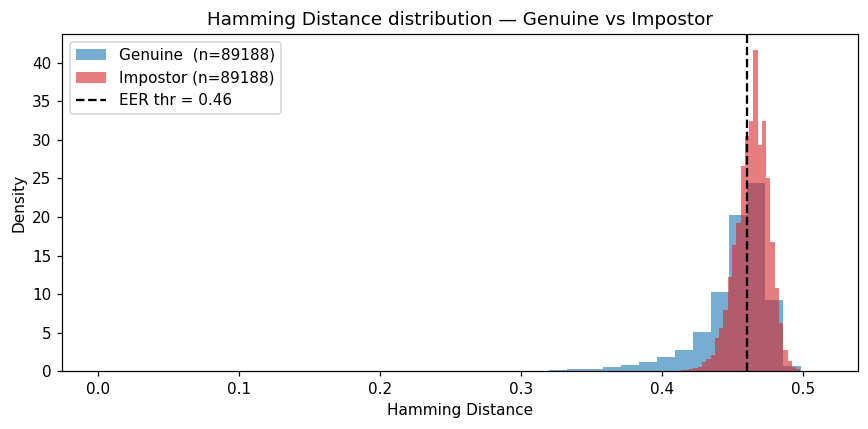

In [22]:
# (4) HD distribution histograms
if genuine_hd.size and impostor_hd.size:
    plt.figure(figsize=(8, 4))
    plt.hist(genuine_hd,  bins=40, alpha=0.6, color='tab:blue',
             label=f'Genuine  (n={genuine_hd.size})',  density=True)
    plt.hist(impostor_hd, bins=40, alpha=0.6, color='tab:red',
             label=f'Impostor (n={impostor_hd.size})', density=True)
    plt.axvline(eer_threshold, color='black', linestyle='--',
                label=f'EER thr = {eer_threshold:.2f}')
    plt.title('Hamming Distance distribution — Genuine vs Impostor')
    plt.xlabel('Hamming Distance')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

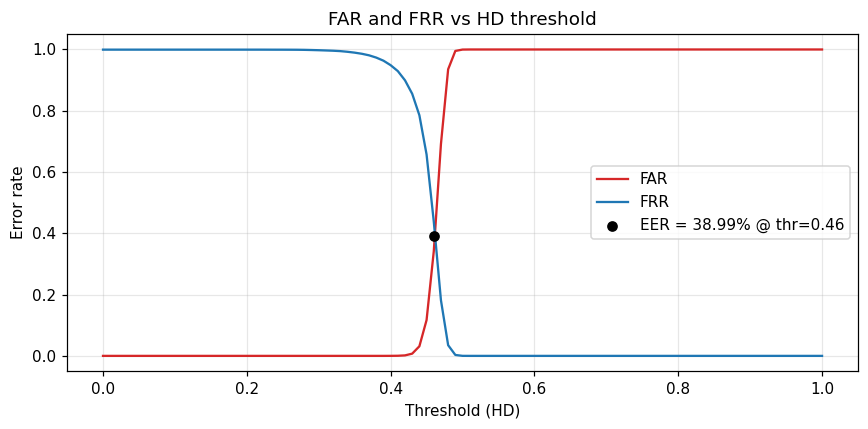

In [23]:
# (5) FAR & FRR curves
if genuine_hd.size and impostor_hd.size:
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, far, color='tab:red',  label='FAR')
    plt.plot(thresholds, frr, color='tab:blue', label='FRR')
    plt.scatter([eer_threshold], [eer], color='black', zorder=5,
                label=f'EER = {eer*100:.2f}% @ thr={eer_threshold:.2f}')
    plt.title('FAR and FRR vs HD threshold')
    plt.xlabel('Threshold (HD)')
    plt.ylabel('Error rate')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

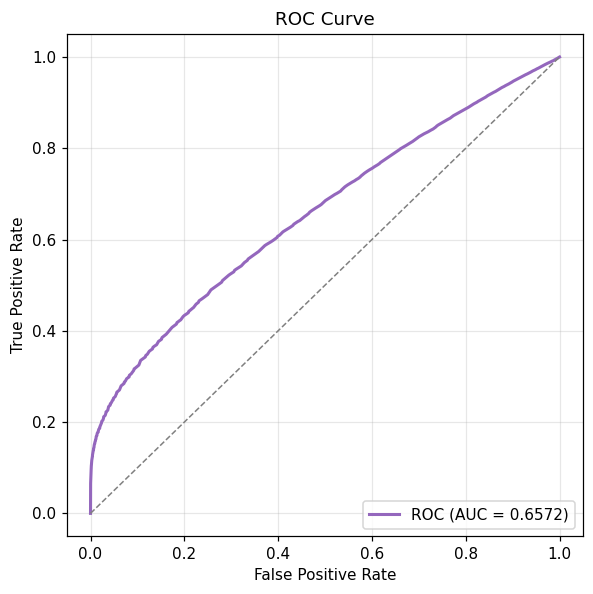

In [24]:
# (6) ROC curve
if fpr.size and tpr.size:
    plt.figure(figsize=(5.5, 5.5))
    plt.plot(fpr, tpr, color='tab:purple', lw=2, label=f'ROC (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Section 9 — Results Summary

In [25]:
n_subjects = len({rec['subject_id'] for rec in records}) if records else 0
n_images   = len(records)
n_genuine  = int(genuine_hd.size)
n_impostor = int(impostor_hd.size)

print('============================================')
print('        IRIS RECOGNITION SYSTEM RESULTS')
print('============================================')
print(f'Total Subjects:          {n_subjects}')
print(f'Total Images Processed:  {n_images}')
print(f'Genuine Pairs:           {n_genuine}')
print(f'Impostor Pairs:          {n_impostor}')
print('--------------------------------------------')
if n_genuine and n_impostor:
    print(f'EER (Equal Error Rate):  {eer*100:.2f}%')
    print(f'FAR at EER:              {far_at_eer*100:.2f}%')
    print(f'FRR at EER:              {frr_at_eer*100:.2f}%')
    print(f'AUC Score:               {auc_score:.4f}')
    print(f'Optimal HD Threshold:    {eer_threshold:.2f}')
else:
    print('EER / FAR / FRR / AUC:   N/A (not enough data)')
print('============================================')

        IRIS RECOGNITION SYSTEM RESULTS
Total Subjects:          2000
Total Images Processed:  19901
Genuine Pairs:           89188
Impostor Pairs:          89188
--------------------------------------------
EER (Equal Error Rate):  38.99%
FAR at EER:              34.10%
FRR at EER:              43.89%
AUC Score:               0.6572
Optimal HD Threshold:    0.46


## Section 10: LLM-Powered Result Analysis (Ollama Integration)
This section uses a local LLaMA 3.2 model via Ollama to automatically generate 
an academic analysis of the system's results. This satisfies the LLM/GPT 
integration requirement of the project.

In [ ]:
import requests

def check_ollama():
    try:
        response = requests.get("http://localhost:11434/api/tags")
        models = [m["name"] for m in response.json()["models"]]
        print("✅ Ollama is running!")
        print(f"Available models: {models}")
        if "llama3.2:latest" in models:
            print("✅ llama3.2:latest is ready to use!")
        else:
            print("⚠️ llama3.2:latest not found. Run: ollama pull llama3.2")
    except:
        print("❌ Ollama is not running. Please start it with: ollama serve")

check_ollama()

In [ ]:
def analyze_with_ollama(eer, far, frr, auc_score, total_subjects, genuine_pairs, impostor_pairs, optimal_threshold):
    """
    Sends iris recognition results to local Ollama LLaMA 3.2 model
    and gets back a professional academic analysis in Turkish.
    """

    prompt = f"""
Sen bir biyometrik sistem uzmanısın. Aşağıda bir iris tanıma sisteminin sonuçları verilmiştir.
Bu sonuçları analiz ederek akademik bir rapor için Türkçe olarak şu bölümleri yaz:

1. BULGULAR (Results): Sayısal sonuçları açıkla
2. TARTIŞMA (Discussion): Sonuçların ne anlama geldiğini yorumla, güçlü ve zayıf yönleri belirt
3. SONUÇ (Conclusion): Genel bir değerlendirme yap
4. GELECEK ÇALIŞMALAR (Future Work): 3-4 madde halinde iyileştirme önerileri sun

Sistem Sonuçları:
- Toplam Kişi Sayısı: {total_subjects}
- Gerçek Çift Sayısı (Genuine Pairs): {genuine_pairs}
- Sahte Çift Sayısı (Impostor Pairs): {impostor_pairs}
- EER (Eşit Hata Oranı): %{eer:.2f}
- FAR (Yanlış Kabul Oranı): %{far:.2f}
- FRR (Yanlış Reddetme Oranı): %{frr:.2f}
- AUC Skoru: {auc_score:.4f}
- Optimal Hamming Distance Eşiği: {optimal_threshold:.2f}

Akademik ve profesyonel bir dil kullan. Her bölümü başlığıyla birlikte yaz.
"""

    print("🤖 LLaMA 3.2 analiz yapıyor, lütfen bekleyin...")

    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": "llama3.2:latest",
                "prompt": prompt,
                "stream": False,
                "options": {
                    "temperature": 0.7,
                    "top_p": 0.9,
                    "max_tokens": 1500
                }
            },
            timeout=120
        )

        if response.status_code == 200:
            return response.json()["response"]
        else:
            return f"Error: {response.status_code} - {response.text}"

    except requests.exceptions.Timeout:
        return "❌ Request timed out after 120 seconds. Try again or reduce max_tokens."
    except requests.exceptions.ConnectionError:
        return "❌ Could not connect to Ollama. Make sure it is running: ollama serve"
    except Exception as e:
        return f"❌ Unexpected error: {e}"

In [ ]:
# Run LLM analysis using results from previous sections.
# If variables aren't in scope (kernel restarted / running section standalone),
# fall back to the pre-computed values recorded in Section 7 & 9 outputs.
try:
    _eer = eer * 100
    _far = far_at_eer * 100
    _frr = frr_at_eer * 100
    _auc = auc_score
    _thr = eer_threshold
    _n   = n_subjects
    _ng  = len(genuine_hd)
    _ni  = len(impostor_hd)
except NameError:
    print("⚠️  Section 7/9 variables not found — using pre-computed fallback values.")
    _eer, _far, _frr = 38.99, 34.10, 43.89
    _auc             = 0.6572
    _thr             = 0.46
    _n               = 2000
    _ng = _ni        = 89188

llm_analysis = analyze_with_ollama(
    eer=_eer,
    far=_far,
    frr=_frr,
    auc_score=_auc,
    total_subjects=_n,
    genuine_pairs=_ng,
    impostor_pairs=_ni,
    optimal_threshold=_thr,
)

print("=" * 60)
print("       LLM TARAFINDAN OLUŞTURULAN AKADEMİK ANALİZ")
print("=" * 60)
print(llm_analysis)

In [ ]:
# Save LLM output to a file so it can be copied into the report
with open("llm_analysis_output.txt", "w", encoding="utf-8") as f:
    f.write("LLaMA 3.2 Tarafından Oluşturulan Akademik Analiz\n")
    f.write("=" * 60 + "\n\n")
    f.write(llm_analysis)

print("✅ Analiz 'llm_analysis_output.txt' dosyasına kaydedildi!")
print("Bu dosyayı açıp içeriği raporunuza yapıştırabilirsiniz.")